# 01 - Estructura de los datos


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src import data_loading as dl

sns.set_theme(style="whitegrid")


## 1. Metadata de secuencias 

In [2]:
train_df = dl.load_train_index()
print(train_df.shape)
train_df.head()


(67208, 5)


,path,file_id,sequence_id,participant_id,phrase
0,train_landmarks/5414471.parquet,5414471,1816796431,217,3 creekhouse
1,train_landmarks/5414471.parquet,5414471,1816825349,107,scales/kuhaylah
2,train_landmarks/5414471.parquet,5414471,1816909464,1,1383 william lanier
3,train_landmarks/5414471.parquet,5414471,1816967051,63,988 franklin lane
4,train_landmarks/5414471.parquet,5414471,1817123330,89,6920 northeast 661st road


In [3]:
train_df.dtypes

path                str
file_id           int64
sequence_id       int64
participant_id    int64
phrase              str
dtype: object

In [4]:
train_df["participant_id"].nunique()
train_df["participant_id"].value_counts().describe()


count      94.000000
mean      714.978723
std       231.889526
min         1.000000
25%       591.750000
50%       794.500000
75%       862.750000
max      1535.000000
Name: count, dtype: float64

## 2. Frases objetivo (`phrase`)

Longitud en caracteres por secuencia.

In [5]:
train_df["phrase_len"] = train_df["phrase"].str.len()
train_df["phrase_len"].describe()

count    67208.000000
mean        17.804636
std          5.727504
min          1.000000
25%         12.000000
50%         17.000000
75%         22.000000
max         31.000000
Name: phrase_len, dtype: float64

## 3. Estructura de un archivo de landmarks (`.parquet`)

Un archivo de la muestra fija (`config.SAMPLE_LANDMARK_PATHS`): cuadros por secuencia, columnas por tipo de landmark (face, pose, manos).

In [6]:
sample_path = dl.landmark_path(config.SAMPLE_LANDMARK_PATHS[0])
sample_landmarks = dl.load_landmarks(sample_path)
sample_landmarks.shape

(161461, 1630)

In [7]:
for lt in config.LANDMARK_TYPES:
    cols = dl.get_landmark_columns(sample_landmarks, lt, "x")
    print(lt, len(cols))

face 468
left_hand 21
pose 33
right_hand 21


## Un cuadro real

La secuencia 1976999033 tiene la mano derecha detectada en el 100% de sus frames, sirve de ejemplo limpio.

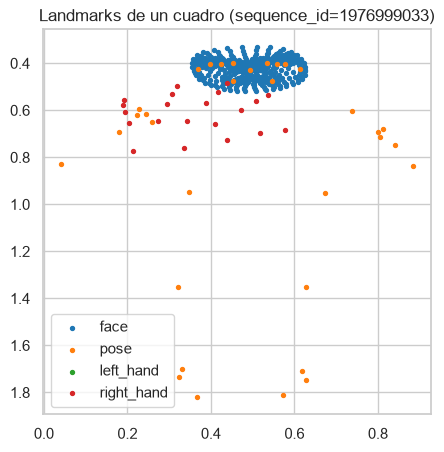

In [8]:
seq = sample_landmarks.loc[1976999033]
frame0 = seq.iloc[0]

colors = {"face": "tab:blue", "pose": "tab:orange", "left_hand": "tab:green", "right_hand": "tab:red"}

fig, ax = plt.subplots(figsize=(5, 5))
for lt, color in colors.items():
    xs = frame0[dl.get_landmark_columns(sample_landmarks, lt, "x")]
    ys = frame0[dl.get_landmark_columns(sample_landmarks, lt, "y")]
    ax.scatter(xs, ys, s=8, label=lt, color=color)
ax.invert_yaxis()
ax.legend()
ax.set_title("Landmarks de un cuadro (sequence_id=1976999033)")
fig.savefig(config.ROOT_DIR / "reports" / "figures" / "01_landmarks_un_cuadro.png", dpi=150, bbox_inches="tight")


## 4. Resumen para el informe

train.csv tiene 67,208 filas, una por secuencia. Las columnas son path y phrase (texto) y file_id, sequence_id, participant_id (enteros) -- nada muy raro ahi. Lo que si llama la atencion es que tan repartidas estan las secuencias entre los 94 participantes: hay uno con solo 1 secuencia y otro con 1535 (la mediana anda en 794), asi que si mas adelante se compara algo por participante hay que tener cuidado con ese desbalance. Las frases van de 1 a 31 caracteres, con mediana 17.

Del lado de los landmarks: cada parquet trae unas 1000 secuencias, y ojo, sequence_id es el indice, no una columna (esto confunde al inicio). Por cuadro son 1630 columnas -- 468 de rostro, 33 de pose y 21 por mano, cada uno en x/y/z. En el grafico se nota bien la diferencia: la cara es un bloque compacto y apretado, pose se riega por toda la imagen, y la mano queda agrupada cerca de la cara, cosa que tiene sentido porque en fingerspelling la mano no se aleja mucho de ahi.